# Data Cleaning & Exploration
Welcome to the sixth lesson! This Jupyter Notebook file is meant to accompany **L06 - Data Cleaning & Exploration.**

Type your solutions for each exercise in the code cells below, and then press **Shift + Enter** to execute your code. Then, check the solution video to see how you did!

### 1. The Machine Learning Process

**Concepts:** A practical ML workflow is iterative, not one-and-done.
- Define target + success metric first (what are you predicting, and how will you judge quality?).
- Split data before modeling so test performance stays unbiased.
- Train a simple baseline first, then improve with cleaner data/features.
- Compare models using the same splits/metrics, then keep the most reliable performer.

### 2. Introduction to Matplotlib and Seaborn

**Concepts:** Visualization is for diagnostics, not just presentation.
- Use `matplotlib` for low-level control and `seaborn` for fast statistical plots.
- `countplot` is ideal for categorical frequency checks (class balance, misspellings, rare categories).
- Histograms/boxplots expose skew and outliers that can distort model training.
- Plot before and after cleaning so you can verify each fix changed what you expected.

### 3. Correcting Categorical Features

**Concepts:** Categorical cleaning makes labels consistent so models and aggregations behave correctly.
- Check unique values (`.unique()`, `.value_counts()`) to find typos, casing, punctuation variants, and nulls.
- Normalize labels with `replace()` mappings (e.g., misspellings -> canonical sector name).
- Re-plot counts after replacement to confirm categories merged as intended.
- Keep one canonical spelling per category; fragmented labels act like fake extra classes.

<font color = 'blue'> **EXERCISE 3.1** </font>

In [1]:
# Import NumPy, Pandas, Pyplot (from Matplotlib), and Seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import tight_layout



In [2]:
# Import Stock Data.csv into a new DataFrame
stock_data = pd.read_csv('../data/raw/stock_data_v2.csv')

# Display the first row
stock_data.head(1)


,Ticker,Name,Sector,Beta,Market Cap,Current Price,Price Target,Price Increase,Return
0,AAPL,APPLE INC,Information Technology,1.09,1081130615,223.84,232.27,8.43,0.038


![Exercise 3.1](../figures/exercise_3_1.png)

In [3]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Ticker          100 non-null    object 
 1   Name            100 non-null    object 
 2   Sector          93 non-null     object 
 3   Beta            100 non-null    float64
 4   Market Cap      100 non-null    int64  
 5   Current Price   100 non-null    float64
 6   Price Target    93 non-null     float64
 7   Price Increase  93 non-null     float64
 8   Return          93 non-null     float64
dtypes: float64(5), int64(1), object(3)
memory usage: 7.2+ KB


In [4]:
# Display the unique values in 'Sector'
stock_data['Sector'].unique()


array(['Information Technology', 'Consumer Discretionary', 'Financials',
       'Health Care', 'Energy', 'Consumer Staples', nan,
       'Telecommunication Services', 'Industrials',
       'Information Technology .', 'Materials', 'Industrial$',
       'Utilities', 'Enersy', 'lndustrials', 'Real Estate'], dtype=object)

<font color = 'blue'> **EXERCISE 3.2** </font>

![Exercise 3.2](../figures/exercise_3_2.png)

In [5]:
# dataframe info
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Ticker          100 non-null    object 
 1   Name            100 non-null    object 
 2   Sector          93 non-null     object 
 3   Beta            100 non-null    float64
 4   Market Cap      100 non-null    int64  
 5   Current Price   100 non-null    float64
 6   Price Target    93 non-null     float64
 7   Price Increase  93 non-null     float64
 8   Return          93 non-null     float64
dtypes: float64(5), int64(1), object(3)
memory usage: 7.2+ KB


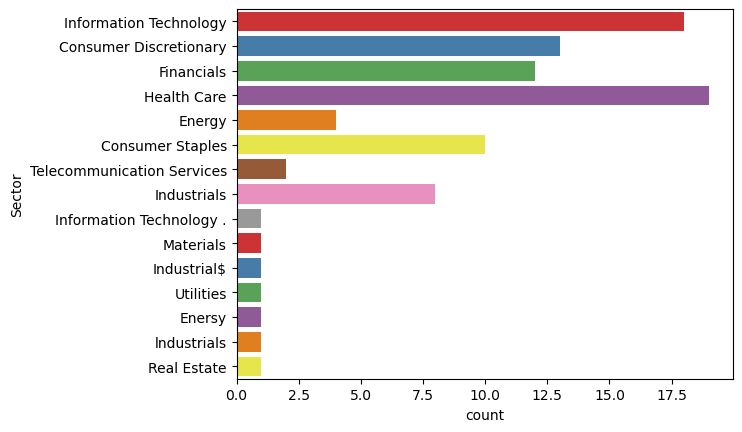

In [6]:
sns.countplot(y='Sector', data=stock_data, hue='Sector', palette='Set1') # hue='Sector'  is what provides multiple colors in the plot.   The palette= is setting a predefined pattern
plt.legend().remove()  # removes the legend
plt.show()

# SNS.Countplot Usage
- Shows the count of each category in the 'Sector' column
- Provides multiple colors for each category using the 'Set1' palette
- This function is useful for visualizing the distribution of categorical data and identifying patterns or outliers.
- This can also be another check for data quality and consistency.
  - For example, it can help identify if there are any missing or incorrect sector labels. In the above example, we can see that 'Enersy' was incorrectly labeled as 'Energy' and 'Industrial$' was incorrectly labeled as 'Industrials'. This can help us ensure that our data is accurate and consistent.

<font color = 'blue'> **EXERCISE 3.3** </font>

![Exercise 3.3](../figures/exercise_3_3.png)

In [7]:
stock_data['Sector'] = stock_data['Sector'].replace({
    'Information Technology .': 'Information Technology',
    'Enersy': 'Energy',
    'Industrial$': 'Industrials',
    'lndustrials': 'Industrials'
},
regex=True
)
stock_data['Sector'].unique()


array(['Information Technology', 'Consumer Discretionary', 'Financials',
       'Health Care', 'Energy', 'Consumer Staples', nan,
       'Telecommunication Services', 'Industrials', 'Materials',
       'Industrial$', 'Utilities', 'Real Estate'], dtype=object)

## Correcting Misspelled Sector Labels

`DataFrame.replace()` with `regex=True` lets you fix dirty categorical values using pattern matching.

### Syntax

```python
df['column'] = df['column'].replace(
    {pattern: replacement, ...},
    regex=True
)
```

- **`df['column']`** — selects the Series (column) to operate on; the result is reassigned back to replace the original column
- **`.replace({...})`** — takes a dictionary where each key is the value (or pattern) to find, and each value is what to replace it with
- **`regex=True`** — tells pandas to treat the dictionary keys as **regular expression patterns** rather than exact string matches; this enables partial matching (e.g., matching a trailing character) instead of requiring the full string to match exactly

### Patterns Applied

| Pattern | Replacement | Issue |
|---|---|---|
| `'Information Technology .'` | `'Information Technology'` | Trailing space + any character (`.` matches any char in regex) |
| `'Enersy'` | `'Energy'` | Typo (`s` instead of `g`) |
| `'Industrial$'` | `'Industrials'` | `$` character instead of `s` (note: `$` normally means end-of-string in regex, but here it matches the literal `$` in the data) |
| `'lndustrials'` | `'Industrials'` | Lowercase `l` instead of uppercase `I` |

Finally, `.unique()` is called to verify the replacements worked — it returns an array of all distinct values in the column, confirming no duplicate or misspelled categories remain.

<font color = 'blue'> **EXERCISE 3.4** </font>

![Exercise 3.4](../figures/exercise_3_4.png)

In [8]:
stock_data['Sector'] = stock_data['Sector'].replace({
    'Materials': 'Industrials',
    'Telecommunication Services': 'Other',
    'Utilities': 'Other',
    'Real Estate': 'Other'
})
stock_data['Sector'].unique()

array(['Information Technology', 'Consumer Discretionary', 'Financials',
       'Health Care', 'Energy', 'Consumer Staples', nan, 'Other',
       'Industrials', 'Industrial$'], dtype=object)

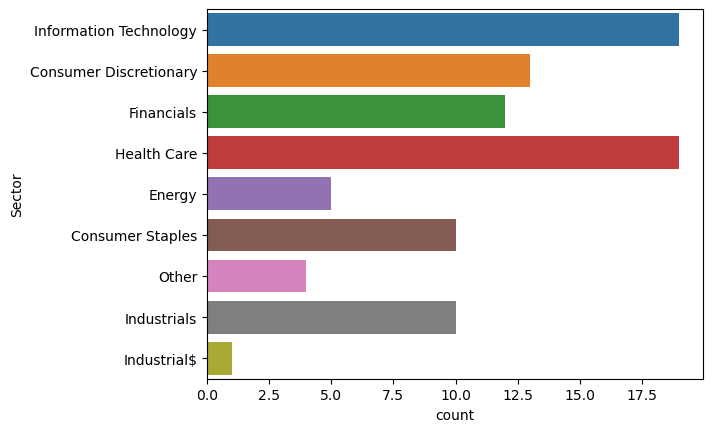

In [9]:
sns.countplot(y='Sector', data=stock_data, hue='Sector', legend=False)
plt.show()

### 4. Outliers & Unwanted Observations

**Concepts:** Outliers can dominate scale-sensitive analysis and hide the true distribution.
- First detect with histograms/boxplots; then create indicator flags (like `is_price_above_5k`) for traceability.
- Decide treatment by context: keep, cap (winsorize), transform (log), or remove.
- If you remove rows, document the rule (for example, threshold-based filtering) and compare distributions before/after.
- Don’t drop blindly: extreme values might be valid business cases, not bad data.

<font color = 'blue'> **EXERCISE 4.1** </font>

![Exercise 4.1](../figures/exercise_4_1.png)

In [10]:
# Display the dimensions of the stock_data DataFrame

stock_data.shape

(100, 9)

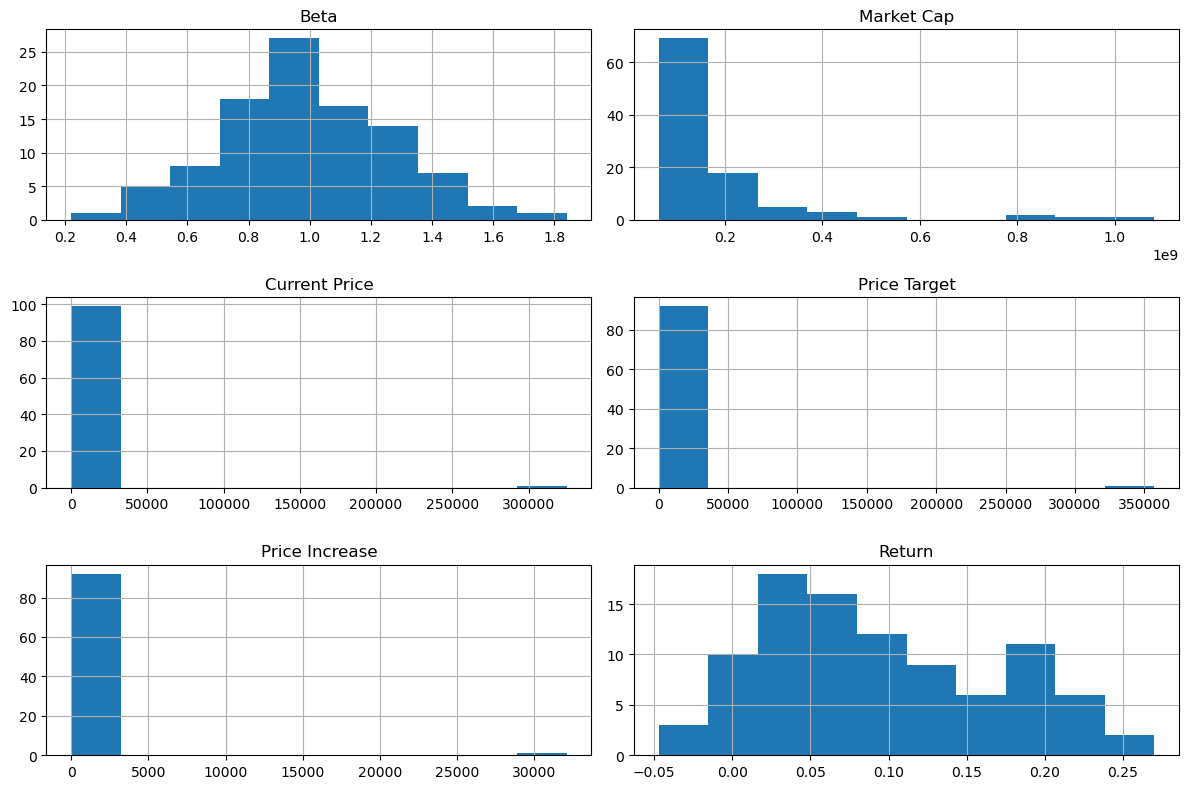

In [11]:
# Display histograms for all continuous features

stock_data.hist(figsize=(12,8))
# for quick and easy where pyplot controls the spacing between graphs
plt.tight_layout() # I think this ends up looking much better

# For manual control of the spacing between graphs
# hspace → vertical spacing between plots
# wspace → horizontal spacing
# plt.subplots_adjust(hspace=0.6, wspace=0.6)

# Show the plot
plt.show()


## Analysis of Histogram
- Beta is a normal distribution
- Seems to be an outlier that is far greater than others.
- The outlier should be examined to determine if it is an error, should be included, or should be excluded

<font color = 'blue'> **EXERCISE 4.2** </font>

![Exercise 4.2](../figures/exercise_4_2.png)

In [12]:
stock_data.info

<bound method DataFrame.info of    Ticker              Name                  Sector  Beta  Market Cap  \
0    AAPL         APPLE INC  Information Technology  1.09  1081130615   
1    AMZN    AMAZON.COM INC  Consumer Discretionary  1.23   960942834   
2    MSFT    MICROSOFT CORP  Information Technology  1.46   869345788   
3   GOOGL    ALPHABET INC-A  Information Technology  1.44   817459888   
4   BRK/A  BERKSHIRE HATH-A              Financials  1.13   534247506   
..    ...               ...                     ...   ...         ...   
95    AMT  AMERICAN TOWER C                   Other  0.46    64886514   
96   ISRG  INTUITIVE SURGIC             Health Care  1.32    64649581   
97    ADP    AUTOMATIC DATA  Information Technology  0.96    64599683   
98   MOLZ  MONDELEZ INTER-A        Consumer Staples  0.74    64235373   
99    AGN      ALLERGAN PLC             Health Care  1.01    63890227   

    Current Price  Price Target  Price Increase  Return  
0          223.84        232.27  

In [13]:
price_above_5k = (stock_data['Current Price'] > 5000).astype(int)
price_above_5k.value_counts()

Current Price
0    99
1     1
Name: count, dtype: int64

In [14]:
stock_data['is_price_above_5k'] = price_above_5k
stock_data.head(1)

,Ticker,Name,Sector,Beta,Market Cap,Current Price,Price Target,Price Increase,Return,is_price_above_5k
0,AAPL,APPLE INC,Information Technology,1.09,1081130615,223.84,232.27,8.43,0.038,0


In [15]:
stock_data['is_price_above_5k']

0     0
1     0
2     0
3     0
4     1
     ..
95    0
96    0
97    0
98    0
99    0
Name: is_price_above_5k, Length: 100, dtype: int64

In [16]:
stock_data[price_above_5k == 1]

,Ticker,Name,Sector,Beta,Market Cap,Current Price,Price Target,Price Increase,Return,is_price_above_5k
4,BRK/A,BERKSHIRE HATH-A,Financials,1.13,534247506,324999.0,357125.0,32126.0,0.099,1


<font color = 'blue'> **EXERCISE 4.3a** </font>

![Exercise 4.3a](../figures/exercise_4_3a.png)

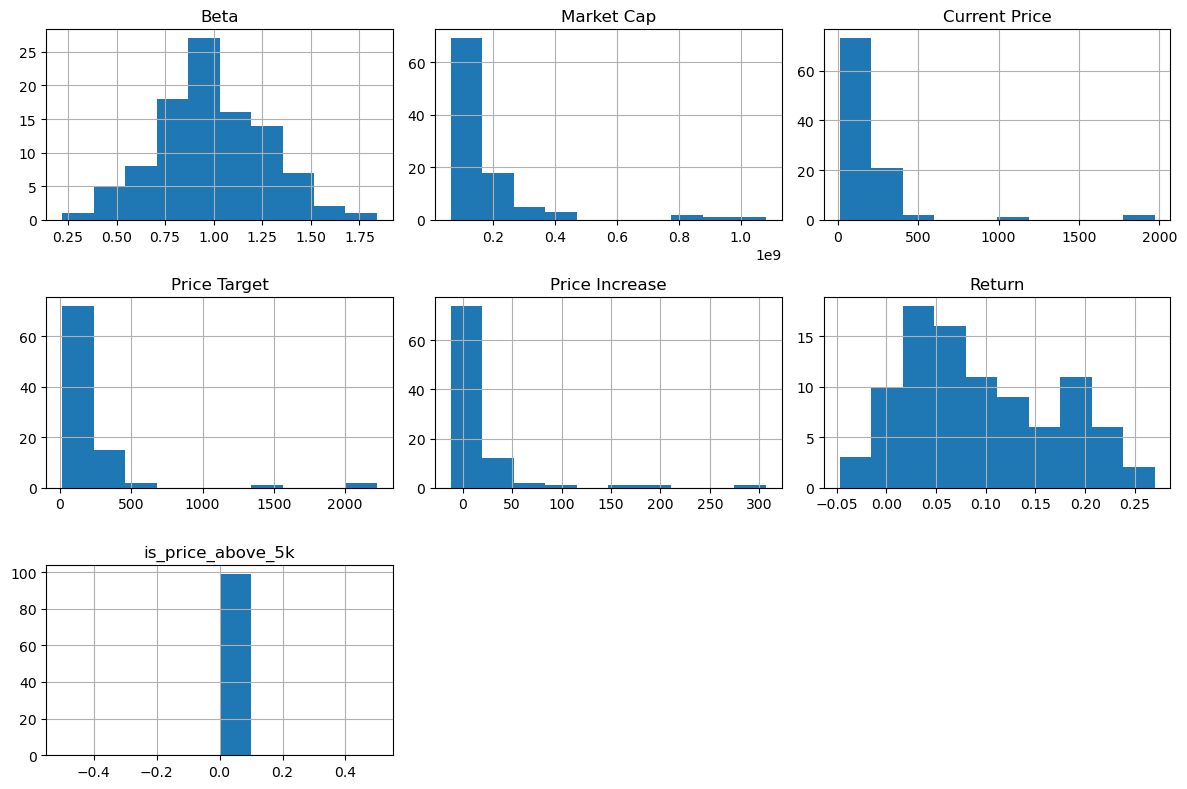

In [17]:
stock_data[stock_data['is_price_above_5k'] == 0].hist(figsize=(12,8))
plt.tight_layout()
plt.show()


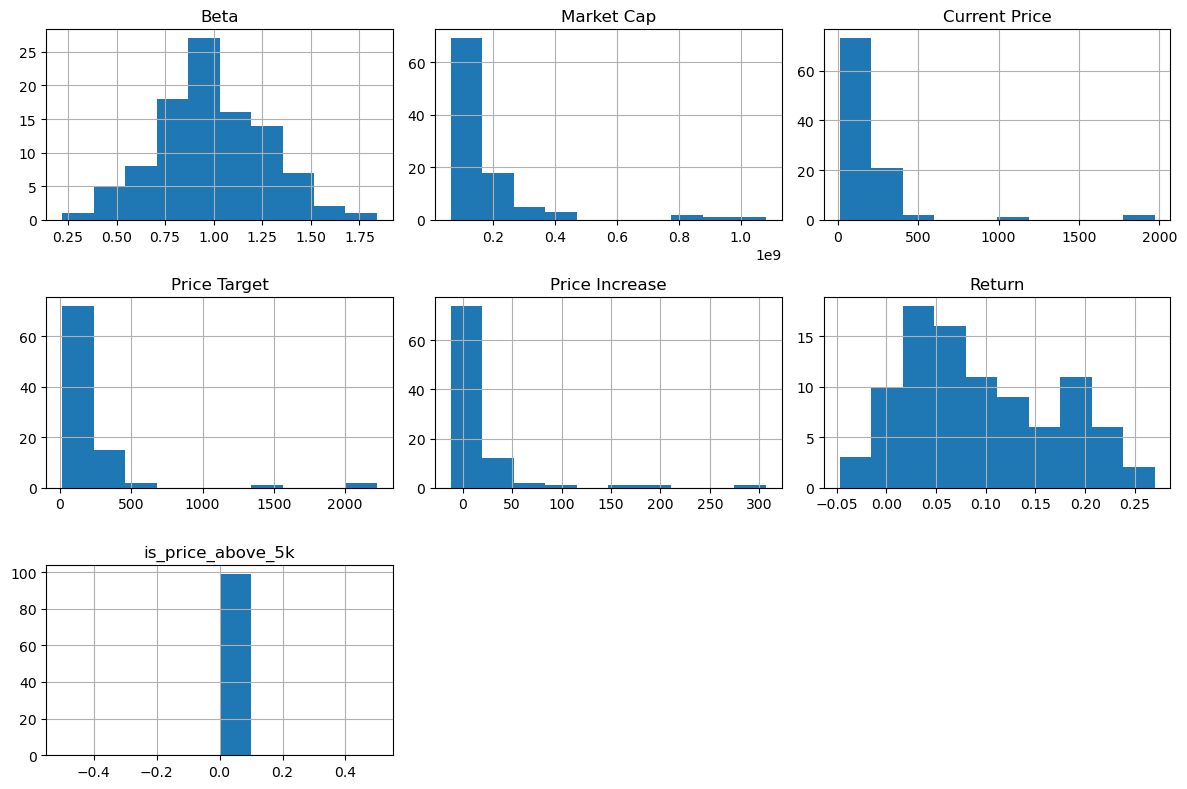

In [18]:
stock_data_wout_sans_brk = stock_data[stock_data['Current Price'] < 300000]
stock_data_wout_sans_brk.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

<font color = 'blue'> **EXERCISE 4.3b** </font>

![Exercise 4.3b](../figures/exercise_4_3b.png)

<font color = 'blue'> **EXERCISE 4.4** </font>

<font color = 'blue'> **EXERCISE 4.5** </font>

<font color = 'blue'> **EXERCISE 4.6** </font>

<font color = 'blue'> **EXERCISE 4.7** </font>

In [ ]:
# Display the box distribution of 'Beta' by 'Sector'



In [ ]:
# Display the box distribution of 'Return' by 'Sector'

